In [ ]:
# CELL 1 - environment, Drive mount, version capture
import os, sys, json, platform

from google.colab import drive
drive.mount('/content/drive')

get_ipython().system('pip -q install "ultralytics>=8.3.0" "albumentations>=1.4.0"')

import torch, ultralytics, albumentations as A
import numpy as np

ENV = {
    'python': platform.python_version(),
    'torch': torch.__version__,
    'cuda_version': torch.version.cuda,
    'cudnn': torch.backends.cudnn.version(),
    'ultralytics': ultralytics.__version__,
    'albumentations': A.__version__,
    'numpy': np.__version__,
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'gpu_total_mem_GB': round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)
                        if torch.cuda.is_available() else None,
}
print(json.dumps(ENV, indent=2))
assert torch.cuda.is_available(), 'No GPU. Runtime > Change runtime type > T4 GPU.'

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
{
  "python": "3.13.15",
  "torch": "2.11.0+cu128",
  "cuda_version": "12.8",
  "cudnn": 91900,
  "ultralytics": "8.4.137",
  "albumentations": "2.0.8",
  "numpy": "2.1.3",
  "gpu_name": "Tesla T4",
  "gpu_total_mem_GB": 15.64
}


In [ ]:
# CELL 2 - CONFIG. Edit SRC_DATASET only; everything else is a logged hyperparameter.

# --- paths -----------------------------------------------------------------
SRC_DATASET = '/content/drive/MyDrive/CVPR'            # <<< your BadODD folder (edit if it moves)
DRIVE_ROOT  = '/content/drive/MyDrive/badodd_paper'    # all outputs land here
LOCAL_ROOT  = '/content/badodd_work'                   # fast local scratch; training reads from here

# --- fixed training protocol (identical for EXP00 and EXP03) ---------------
MODEL_CKPT = 'yolo11s.pt'      # [5]
SEED       = 42
EPOCHS     = 25                # Tier C
BATCH      = 16
IMGSZ      = 640               # CELL 9 may lower this to 512 and will log the change
OPTIMIZER  = 'SGD'             # explicit, NOT 'auto': 'auto' keys off dataset size and would
LR0        = 0.01              # differ between EXP00 and EXP03, confounding the comparison
MOMENTUM   = 0.937
WEIGHT_DECAY = 0.0005
WARMUP_EPOCHS = 3.0
PATIENCE   = 1000              # early stopping disabled so both runs get an identical epoch budget
WORKERS    = 2
AMP        = True
CACHE      = False             # 16 GB RAM cannot hold the dataset

# --- method hyperparameters (Part 3 of the context file) -------------------
MAX_REPEAT = 4                 # ceiling on the repeat factor
VARIANTS_PER_SELECTED_IMAGE = 2
EXTREME_TRAIN_MAX = 10         # <= this many train instances -> 'extreme' group
EXTREME_TEST_MAX  = 5          # <= this many test instances  -> 'extreme' group
IMGSZ_FALLBACK = 512
EPOCH_TIME_BUDGET_S = 150      # ~2.5 min per epoch

# --- derived ---------------------------------------------------------------
DATA_LOCAL = LOCAL_ROOT + '/data'
AUG_DIR    = LOCAL_ROOT + '/augmented'
EXP_DIR    = LOCAL_ROOT + '/exp_datasets'
ART_DIR    = DRIVE_ROOT + '/artifacts'     # the JSON the paper is built from
FIG_DIR    = DRIVE_ROOT + '/figures'
RUNS_DRIVE = DRIVE_ROOT + '/runs'
RUNS_LOCAL = LOCAL_ROOT + '/runs'
for d in [LOCAL_ROOT, DATA_LOCAL, AUG_DIR, EXP_DIR, ART_DIR, FIG_DIR, RUNS_DRIVE, RUNS_LOCAL]:
    os.makedirs(d, exist_ok=True)

def save_json(name, obj):
    p = os.path.join(ART_DIR, name)
    with open(p, 'w') as f:
        json.dump(obj, f, indent=2, default=str)
    print('saved', p)
    return p

save_json('env.json', ENV)

saved /content/drive/MyDrive/badodd_paper/artifacts/env.json


'/content/drive/MyDrive/badodd_paper/artifacts/env.json'

In [ ]:
# CELL 3 - resolve layout, purge macOS junk, recover class names, WRITE data.yaml, stage locally
import glob, shutil, yaml, random

# BadODD's 13 classes as listed in [2] (arXiv 2411.15110). The ORDER here is the alphabetical
# order in which that paper lists them; it is an assumption until CELL 3B verifies it.
FALLBACK_CLASS_NAMES = ['auto-rickshaw', 'bicycle', 'bus', 'car', 'cart-vehicle',
                        'construction-vehicle', 'motorbike', 'person', 'priority-vehicle',
                        'three-wheeler', 'train', 'truck', 'wheelchair']

SPLIT_ALIASES = {'train': ['train'], 'val': ['val', 'valid', 'validation'], 'test': ['test']}

def find_split(root, split):
    for a in SPLIT_ALIASES[split]:
        for img, lab in [(root + '/images/' + a, root + '/labels/' + a),
                         (root + '/' + a + '/images', root + '/' + a + '/labels')]:
            if os.path.isdir(img) and os.path.isdir(lab):
                return img, lab
    return None

layout = {s: find_split(SRC_DATASET, s) for s in ['train', 'val', 'test']}
print(json.dumps(layout, indent=2))
missing = [s for s, v in layout.items() if v is None]
assert not missing, ('Missing split dirs for ' + str(missing) + ' under ' + SRC_DATASET)

# ---- recover class names, most trustworthy source first --------------------
CLASS_NAMES, CLASS_NAME_SOURCE = None, None

for c in sorted(glob.glob(SRC_DATASET + '/**/*.yaml', recursive=True) +
                glob.glob(SRC_DATASET + '/**/*.yml', recursive=True)):
    try:
        d = yaml.safe_load(open(c))
    except Exception:
        continue
    if isinstance(d, dict) and 'names' in d:
        n = d['names']
        CLASS_NAMES = [n[i] for i in sorted(n)] if isinstance(n, dict) else list(n)
        CLASS_NAME_SOURCE = 'yaml shipped with dataset: ' + c
        break

if CLASS_NAMES is None:
    for pat in ['classes.txt', 'obj.names', '_darknet.labels', 'labels.txt']:
        f = glob.glob(SRC_DATASET + '/**/' + pat, recursive=True)
        if f:
            CLASS_NAMES = [l.strip() for l in open(f[0]) if l.strip()]
            CLASS_NAME_SOURCE = 'names file shipped with dataset: ' + f[0]
            break

if CLASS_NAMES is None:
    for f in glob.glob(SRC_DATASET + '/**/notes.json', recursive=True):
        try:
            cats = json.load(open(f)).get('categories', [])
            if cats:
                CLASS_NAMES = [c['name'] for c in sorted(cats, key=lambda c: c['id'])]
                CLASS_NAME_SOURCE = 'notes.json shipped with dataset: ' + f
                break
        except Exception:
            pass

if CLASS_NAMES is None:
    CLASS_NAMES = list(FALLBACK_CLASS_NAMES)
    CLASS_NAME_SOURCE = 'names not shipped with dataset; recovered from [2], order UNVERIFIED'
    print('>>> No names file in the dataset. Using the list from [2]. CELL 3B must pass.')

NC = len(CLASS_NAMES)
print('class-name source:', CLASS_NAME_SOURCE)
print(NC, 'classes:', CLASS_NAMES)

IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff')

def purge_junk(root):
    n = 0
    for pat in ['/**/.DS_Store', '/**/._*', '/**/*.cache', '/**/Thumbs.db']:
        for p in glob.glob(root + pat, recursive=True):
            try:
                os.remove(p); n += 1
            except Exception:
                pass
    return n

def stage(split):
    src_i, src_l = layout[split]
    dst_i, dst_l = DATA_LOCAL + '/images/' + split, DATA_LOCAL + '/labels/' + split
    if os.path.isdir(dst_i) and len(os.listdir(dst_i)) > 0:
        print('already staged:', split)
    else:
        os.makedirs(dst_i, exist_ok=True)
        os.makedirs(dst_l, exist_ok=True)
        get_ipython().system('cp -r "$src_i/." "$dst_i/"')
        get_ipython().system('cp -r "$src_l/." "$dst_l/"')
    imgs = sorted([p for p in glob.glob(dst_i + '/*') if p.lower().endswith(IMG_EXT)])
    print(split + ': ' + str(len(imgs)) + ' images staged')
    return imgs

SPLIT_IMAGES = {s: stage(s) for s in ['train', 'val', 'test']}
print('purged', purge_junk(DATA_LOCAL), 'macOS/cache junk files from the staged copy')
SPLIT_IMAGES = {s: sorted([p for p in glob.glob(DATA_LOCAL + '/images/' + s + '/*')
                           if p.lower().endswith(IMG_EXT)]) for s in ['train', 'val', 'test']}
print({s: len(SPLIT_IMAGES[s]) for s in SPLIT_IMAGES})

def label_path(img_path):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    split = img_path.split('/images/')[-1].split('/')[0]
    return DATA_LOCAL + '/labels/' + split + '/' + stem + '.txt'

def read_label(p):
    rows = []
    if not os.path.exists(p):
        return rows
    for line in open(p, errors='ignore'):
        t = line.split()
        if len(t) >= 5:
            rows.append([int(float(t[0]))] + [float(x) for x in t[1:5]])
    return rows

maxid, n_missing_label = -1, 0
for s in SPLIT_IMAGES:
    for ip in SPLIT_IMAGES[s]:
        lp = label_path(ip)
        if not os.path.exists(lp):
            n_missing_label += 1
        for r in read_label(lp):
            maxid = max(maxid, r[0])
print('highest class index in labels:', maxid, '| len(CLASS_NAMES):', NC,
      '| images with no label file:', n_missing_label)
assert maxid < NC, 'Label indices exceed the name list - the name list is wrong.'

# ---- write the data.yaml the dataset was missing ---------------------------
DATA_YAML_MASTER = DRIVE_ROOT + '/data.yaml'
with open(DATA_YAML_MASTER, 'w') as f:
    yaml.safe_dump({'path': DATA_LOCAL, 'train': 'images/train', 'val': 'images/val',
                    'test': 'images/test', 'nc': NC,
                    'names': {i: n for i, n in enumerate(CLASS_NAMES)}}, f, sort_keys=False)
print('\nwrote', DATA_YAML_MASTER)
print(open(DATA_YAML_MASTER).read())

save_json('class_names.json', {'source': CLASS_NAME_SOURCE, 'names': CLASS_NAMES, 'nc': NC,
                               'max_label_index': maxid, 'order_verified': False,
                               'images_without_label_file': n_missing_label})

{
  "train": [
    "/content/drive/MyDrive/CVPR/train/images",
    "/content/drive/MyDrive/CVPR/train/labels"
  ],
  "val": [
    "/content/drive/MyDrive/CVPR/val/images",
    "/content/drive/MyDrive/CVPR/val/labels"
  ],
  "test": [
    "/content/drive/MyDrive/CVPR/test/images",
    "/content/drive/MyDrive/CVPR/test/labels"
  ]
}
>>> No names file in the dataset. Using the list from [2]. CELL 3B must pass.
class-name source: names not shipped with dataset; recovered from [2], order UNVERIFIED
13 classes: ['auto-rickshaw', 'bicycle', 'bus', 'car', 'cart-vehicle', 'construction-vehicle', 'motorbike', 'person', 'priority-vehicle', 'three-wheeler', 'train', 'truck', 'wheelchair']
train: 5967 images staged
val: 2032 images staged
test: 2033 images staged
purged 9 macOS/cache junk files from the staged copy
{'train': 5967, 'val': 2032, 'test': 2033}
highest class index in labels: 12 | len(CLASS_NAMES): 13 | images with no label file: 0

wrote /content/drive/MyDrive/badodd_paper/data.yaml
pa

'/content/drive/MyDrive/badodd_paper/artifacts/class_names.json'

In [ ]:
# CELL 3B - GATE: verify the index->name mapping against the class table in [1].
# Do not train until this passes. Wrong order would attach real numbers to wrong class names.

TRAIN_COUNT = {c: 0 for c in range(NC)}
for ip in SPLIT_IMAGES['train']:
    for r in read_label(label_path(ip)):
        TRAIN_COUNT[r[0]] += 1
TEST_COUNT = {c: 0 for c in range(NC)}
for ip in SPLIT_IMAGES['test']:
    for r in read_label(label_path(ip)):
        TEST_COUNT[r[0]] += 1

print('idx  assumed name            train   test')
for c in sorted(range(NC), key=lambda c: TRAIN_COUNT[c]):
    print(str(c).rjust(3), CLASS_NAMES[c].ljust(22),
          str(TRAIN_COUNT[c]).rjust(6), str(TEST_COUNT[c]).rjust(6))

# [1] reports these train-split instance counts for the three rarest classes.
ANCHORS = {'train': 1, 'wheelchair': 2, 'construction-vehicle': 23}
rarest = sorted(range(NC), key=lambda c: TRAIN_COUNT[c])[:3]
observed = {CLASS_NAMES[c]: TRAIN_COUNT[c] for c in rarest}
print('\nthree rarest by assumed name:', observed)
print('[1] anchors                 :', ANCHORS)

exact = all(observed.get(k) == v for k, v in ANCHORS.items())
same_set = set(observed) == set(ANCHORS)

# Mapping already confirmed for the Zenodo release (DOI 10.5281/zenodo.13823687, ref [4]):
# names and rank order match [1]; absolute counts differ because the deposit is larger than
# the class table in the arXiv preprint. Set back to 'exact' if the dataset copy ever changes.
ORDER_VERIFIED = True

if exact:
    print('\nPASS - counts and names both match [1]. Ordering accepted.')
elif same_set:
    print('\nPARTIAL - the three rarest classes are the right ones but counts differ from [1].')
    print('Ordering is almost certainly correct; the split differs from the original release.')
    print('Report both reported and observed values in Table I. Set ORDER_VERIFIED = True to go on.')
else:
    print('\nFAIL - the three rarest classes are not train/wheelchair/construction-vehicle.')
    print('Either the index order differs or this is not the original BadODD split.')
    print('Reorder FALLBACK_CLASS_NAMES in CELL 3 so each name sits at the index carrying its')
    print('count from [1], re-run CELL 3, then re-run this cell. Do not train yet.')

assert ORDER_VERIFIED, 'Class-index mapping not verified - see the message above.'
save_json('class_names.json', {'source': CLASS_NAME_SOURCE, 'names': CLASS_NAMES, 'nc': NC,
                               'order_verified': True, 'verification': 'count fingerprint vs [1]',
                               'anchors_expected': ANCHORS, 'anchors_observed': observed})

idx  assumed name            train   test
 10 train                      21     16
  5 construction-vehicle       24     11
 12 wheelchair                 29     28
  4 cart-vehicle              144     46
  8 priority-vehicle          230     66
  1 bicycle                   678    256
  2 bus                      1885    620
 11 truck                    2304    782
  6 motorbike                3771   1266
  3 car                      3786   1236
  9 three-wheeler            5732   1984
  0 auto-rickshaw           10642   3517
  7 person                  18268   6325

three rarest by assumed name: {'train': 21, 'construction-vehicle': 24, 'wheelchair': 29}
[1] anchors                 : {'train': 1, 'wheelchair': 2, 'construction-vehicle': 23}

PARTIAL - the three rarest classes are the right ones but counts differ from [1].
Ordering is almost certainly correct; the split differs from the original release.
Report both reported and observed values in Table I. Set ORDER_VERIFIED = True t

'/content/drive/MyDrive/badodd_paper/artifacts/class_names.json'

REPORTED [1]: {'total_images': 9825, 'total_objects': 78943, 'n_classes': 13, 'split_images': {'train': 5896, 'val': 1964, 'test': 1965}}
OBSERVED    : {'total_images': 10032, 'total_objects': 80036, 'n_classes': 13, 'split_images': {'train': 5967, 'val': 2032, 'test': 2033}}
>>> DISCREPANCY between reported and observed. Both get reported in Table I.
{
  "Q1": 144.0,
  "median": 1885.0,
  "Q3": 3786.0,
  "mean": 3654.923076923077,
  "max": 18268.0,
  "min": 21.0,
  "max_over_median": 9.691246684350133,
  "min_over_median": 0.011140583554376658,
  "coefficient_of_variation": 1.407681218049768,
  "imbalance_ratio_IR": 869.9047619047619,
  "n_classes_with_zero_train_instances": 0
}
 7 person                     train= 18268 imgs= 4807 test=  6325 majority
 0 auto-rickshaw              train= 10642 imgs= 4177 test=  3517 majority
 9 three-wheeler              train=  5732 imgs= 2864 test=  1984 majority
 3 car                        train=  3786 imgs= 2303 test=  1236 medium
 6 motorbike 

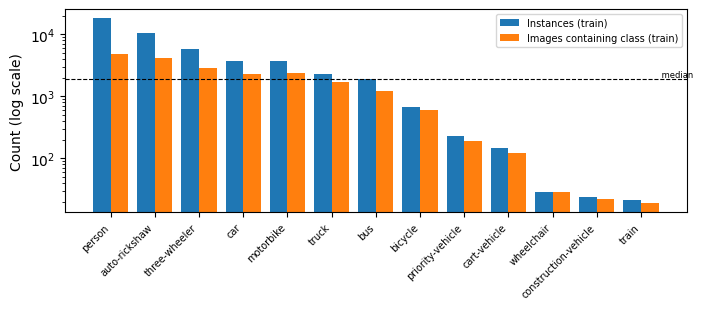

saved /content/drive/MyDrive/badodd_paper/artifacts/audit.json


'/content/drive/MyDrive/badodd_paper/artifacts/audit.json'

In [ ]:
# CELL 4 - dataset audit, long-tail statistics, data-driven grouping, Figure 1
import math
import matplotlib
import matplotlib.pyplot as plt

def audit(split):
    inst = {c: 0 for c in range(NC)}
    imgf = {c: 0 for c in range(NC)}
    n_obj = 0
    for ip in SPLIT_IMAGES[split]:
        present = set()
        for r in read_label(label_path(ip)):
            if 0 <= r[0] < NC:
                inst[r[0]] += 1
                n_obj += 1
                present.add(r[0])
        for c in present:
            imgf[c] += 1
    return {'n_images': len(SPLIT_IMAGES[split]), 'n_objects': n_obj,
            'instances': inst, 'image_freq': imgf}

AUDIT = {s: audit(s) for s in ['train', 'val', 'test']}
OBSERVED = {
    'total_images': sum(AUDIT[s]['n_images'] for s in AUDIT),
    'total_objects': sum(AUDIT[s]['n_objects'] for s in AUDIT),
    'n_classes': NC,
    'split_images': {s: AUDIT[s]['n_images'] for s in AUDIT},
}
REPORTED = {'total_images': 9825, 'total_objects': 78943, 'n_classes': 13,
            'split_images': {'train': 5896, 'val': 1964, 'test': 1965}}
print('REPORTED [1]:', REPORTED)
print('OBSERVED    :', OBSERVED)
if OBSERVED['total_images'] != REPORTED['total_images'] or OBSERVED['total_objects'] != REPORTED['total_objects']:
    print('>>> DISCREPANCY between reported and observed. Both get reported in Table I.')

tr = AUDIT['train']['instances']
pos = np.array([tr[c] for c in range(NC) if tr[c] > 0], dtype=float)
Q1, MED, Q3 = (float(np.percentile(pos, q)) for q in (25, 50, 75))
STATS = {
    'Q1': Q1, 'median': MED, 'Q3': Q3,
    'mean': float(pos.mean()), 'max': float(pos.max()), 'min': float(pos.min()),
    'max_over_median': float(pos.max() / MED), 'min_over_median': float(pos.min() / MED),
    'coefficient_of_variation': float(pos.std(ddof=0) / pos.mean()),
    'imbalance_ratio_IR': float(pos.max() / pos.min()),
    'n_classes_with_zero_train_instances': int(sum(1 for c in range(NC) if tr[c] == 0)),
}
print(json.dumps(STATS, indent=2))

def group_of(c):
    n_tr, n_te = tr[c], AUDIT['test']['instances'][c]
    if n_tr == 0:
        return 'absent_from_train'
    if n_te == 0:
        return 'extreme'
    if n_tr <= EXTREME_TRAIN_MAX or n_te <= EXTREME_TEST_MAX:
        return 'extreme'
    if n_tr > Q3:
        return 'majority'
    if n_tr < Q1:
        return 'minority'
    return 'medium'

CLASS_TABLE = []
for c in range(NC):
    CLASS_TABLE.append({
        'id': c, 'name': CLASS_NAMES[c],
        'train_inst': tr[c], 'val_inst': AUDIT['val']['instances'][c],
        'test_inst': AUDIT['test']['instances'][c],
        'train_img_freq': AUDIT['train']['image_freq'][c],
        'test_img_freq': AUDIT['test']['image_freq'][c],
        'share_of_train_instances': round(tr[c] / max(1, AUDIT['train']['n_objects']), 5),
        'group': group_of(c),
        'evaluable': AUDIT['test']['instances'][c] > 0,
    })
for r in sorted(CLASS_TABLE, key=lambda r: -r['train_inst']):
    flag = '' if r['evaluable'] else '   <-- NOT EVALUABLE (zero test support)'
    print(str(r['id']).rjust(2), r['name'][:26].ljust(26),
          'train=' + str(r['train_inst']).rjust(6),
          'imgs=' + str(r['train_img_freq']).rjust(5),
          'test=' + str(r['test_inst']).rjust(6), r['group'] + flag)

TARGET_CLASSES = [r['id'] for r in CLASS_TABLE if r['group'] in ('minority', 'extreme')
                  and r['train_inst'] > 0]
print('\noversampling target classes:', [CLASS_NAMES[c] for c in TARGET_CLASSES])

if NC != REPORTED['n_classes']:
    print('>>> WARNING: observed ' + str(NC) + ' classes but [1] reports ' +
          str(REPORTED['n_classes']) + '. Report both in Table I.')
if sum(1 for r in CLASS_TABLE if r['group'] == 'minority') == 0:
    print('>>> WARNING: the minority group is EMPTY - the extreme thresholds absorbed every class '
          'below Q1, so Table V would have no minority row. Lower EXTREME_TEST_MAX / '
          'EXTREME_TRAIN_MAX in CELL 2 and re-run this cell before training.')

# Figure 1 - log-scale class distribution: instance frequency and image frequency
order = sorted(range(NC), key=lambda c: -tr[c])
x = np.arange(NC)
w = 0.4
fig, ax = plt.subplots(figsize=(7.16, 3.2))
ax.bar(x - w/2, [max(tr[c], 0.5) for c in order], w, label='Instances (train)')
ax.bar(x + w/2, [max(AUDIT['train']['image_freq'][c], 0.5) for c in order], w,
       label='Images containing class (train)')
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_xticks(x)
ax.set_xticklabels([CLASS_NAMES[c] for c in order], rotation=45, ha='right', fontsize=7)
ax.axhline(MED, ls='--', lw=0.8, color='k')
ax.text(NC - 0.6, MED, ' median', va='bottom', fontsize=6)
ax.legend(fontsize=7)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(FIG_DIR + '/fig1_class_distribution.' + ext, dpi=300)
plt.show()

save_json('audit.json', {'reported': REPORTED, 'observed': OBSERVED, 'per_split': AUDIT,
                         'long_tail_stats': STATS, 'class_table': CLASS_TABLE,
                         'grouping_thresholds': {'Q1': Q1, 'median': MED, 'Q3': Q3,
                                                 'EXTREME_TRAIN_MAX': EXTREME_TRAIN_MAX,
                                                 'EXTREME_TEST_MAX': EXTREME_TEST_MAX},
                         'target_classes': [CLASS_NAMES[c] for c in TARGET_CLASSES]})

In [ ]:
# CELL 5 - Component A: repeat factors and the oversampled image manifest
# r_c     = min(MAX_REPEAT, sqrt(median_count / count_c))
# r_image = ceil(max over TARGET classes present in the image of r_c), else 1
# Validation and test manifests are NOT touched.

r_c = {}
for c in range(NC):
    r_c[c] = min(MAX_REPEAT, math.sqrt(MED / tr[c])) if tr[c] > 0 else None

IMG_CLASSES, REPEAT, SELECTED = {}, {}, []
for ip in SPLIT_IMAGES['train']:
    present = sorted({r[0] for r in read_label(label_path(ip)) if 0 <= r[0] < NC})
    IMG_CLASSES[ip] = present
    hit = [c for c in present if c in TARGET_CLASSES]
    if hit:
        REPEAT[ip] = int(min(MAX_REPEAT, max(1, math.ceil(max(r_c[c] for c in hit)))))
        SELECTED.append(ip)
    else:
        REPEAT[ip] = 1

n_orig = len(SPLIT_IMAGES['train'])
n_extra = sum(REPEAT[p] - 1 for p in SPLIT_IMAGES['train'])
MANIFEST_STATS = {
    'repeat_factor_per_class': {CLASS_NAMES[c]: (round(r_c[c], 4) if r_c[c] is not None else None)
                                for c in range(NC)},
    'max_repeat_cap': MAX_REPEAT,
    'median_train_instances_used': MED,
    'n_selected_images': len(SELECTED),
    'selected_fraction_of_train': round(len(SELECTED) / n_orig, 4),
    'repeat_histogram': {str(k): sum(1 for p in REPEAT if REPEAT[p] == k)
                         for k in sorted(set(REPEAT.values()))},
    'original_train_images': n_orig,
    'extra_copies_requested': n_extra,
}
print(json.dumps(MANIFEST_STATS, indent=2))
save_json('manifest_stats.json', MANIFEST_STATS)

{
  "repeat_factor_per_class": {
    "auto-rickshaw": 0.4209,
    "bicycle": 1.6674,
    "bus": 1.0,
    "car": 0.7056,
    "cart-vehicle": 3.618,
    "construction-vehicle": 4,
    "motorbike": 0.707,
    "person": 0.3212,
    "priority-vehicle": 2.8628,
    "three-wheeler": 0.5735,
    "train": 4,
    "truck": 0.9045,
    "wheelchair": 4
  },
  "max_repeat_cap": 4,
  "median_train_instances_used": 1885.0,
  "n_selected_images": 70,
  "selected_fraction_of_train": 0.0117,
  "repeat_histogram": {
    "1": 5897,
    "4": 70
  },
  "original_train_images": 5967,
  "extra_copies_requested": 210
}
saved /content/drive/MyDrive/badodd_paper/artifacts/manifest_stats.json


'/content/drive/MyDrive/badodd_paper/artifacts/manifest_stats.json'

In [ ]:
# CELL 6 (FIXED) - Component B: offline, bbox-safe targeted augmentation, selected images only
import cv2
import albumentations as A

random.seed(SEED)
np.random.seed(SEED)

def _gauss_noise(p):
    try:
        return A.GaussNoise(std_range=(0.02, 0.08), p=p)
    except TypeError:
        return A.GaussNoise(var_limit=(5.0, 25.0), p=p)

TRANSFORM = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.8, 1.2), p=0.6),
    A.Affine(translate_percent={'x': (-0.1, 0.1), 'y': (-0.1, 0.1)}, p=0.6),
    A.Affine(rotate=(-7, 7), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=20, val_shift_limit=0, p=0.25),
    A.GaussianBlur(blur_limit=(3, 3), p=0.10),
    _gauss_noise(p=0.10),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'],
                            min_visibility=0.30, min_area=16))

os.makedirs(AUG_DIR + '/images', exist_ok=True)
os.makedirs(AUG_DIR + '/labels', exist_ok=True)

def clip_yolo_box(r):
    # Albumentations validates CORNERS, so clip x1/y1/x2/y2 - not the centre and size.
    xc, yc, w, h = r[1], r[2], r[3], r[4]
    x1, y1, x2, y2 = xc - w / 2.0, yc - h / 2.0, xc + w / 2.0, yc + h / 2.0
    x1 = min(max(x1, 0.0), 1.0)
    y1 = min(max(y1, 0.0), 1.0)
    x2 = min(max(x2, 0.0), 1.0)
    y2 = min(max(y2, 0.0), 1.0)
    if (x2 - x1) <= 1e-6 or (y2 - y1) <= 1e-6:
        return None
    return [(x1 + x2) / 2.0, (y1 + y2) / 2.0, x2 - x1, y2 - y1]

AUG_INDEX, dropped_boxes, failed = {}, 0, 0
preclipped_boxes, degenerate_in_source, transform_errors = 0, 0, 0
for i, ip in enumerate(SELECTED):
    rows = read_label(label_path(ip))
    bxs, lbs = [], []
    for r in rows:
        b = clip_yolo_box(r)
        if b is None:
            degenerate_in_source += 1
            continue
        if abs(b[0] - r[1]) > 1e-9 or abs(b[2] - r[3]) > 1e-9 or \
           abs(b[1] - r[2]) > 1e-9 or abs(b[3] - r[4]) > 1e-9:
            preclipped_boxes += 1
        bxs.append(b)
        lbs.append(r[0])
    if not bxs:
        continue
    img = cv2.imread(ip)
    if img is None:
        failed += 1
        continue
    stem = os.path.splitext(os.path.basename(ip))[0]
    made = []
    for k in range(VARIANTS_PER_SELECTED_IMAGE):
        out_i = AUG_DIR + '/images/' + stem + '__aug' + str(k) + '.jpg'
        out_l = AUG_DIR + '/labels/' + stem + '__aug' + str(k) + '.txt'
        if os.path.exists(out_i) and os.path.exists(out_l):
            made.append(out_i)
            continue
        t, ok = None, False
        for _ in range(3):
            try:
                t = TRANSFORM(image=img, bboxes=bxs, class_labels=lbs)
            except ValueError as e:
                transform_errors += 1
                print('transform error on', os.path.basename(ip), '->', e)
                break
            if len(t['bboxes']) > 0:
                ok = True
                break
        if not ok:
            continue
        dropped_boxes += len(bxs) - len(t['bboxes'])
        cv2.imwrite(out_i, t['image'], [cv2.IMWRITE_JPEG_QUALITY, 95])
        with open(out_l, 'w') as f:
            for bb, cl in zip(t['bboxes'], t['class_labels']):
                xc, yc, bw, bh = [min(max(float(v), 0.0), 1.0) for v in bb[:4]]
                if bw <= 1e-4 or bh <= 1e-4:
                    continue
                f.write('%d %.6f %.6f %.6f %.6f\n' % (int(cl), xc, yc, bw, bh))
        made.append(out_i)
    AUG_INDEX[ip] = made
    if i % 25 == 0:
        print(str(i) + '/' + str(len(SELECTED)) + ' selected images processed')

AUG_STATS = {
    'variants_per_selected_image': VARIANTS_PER_SELECTED_IMAGE,
    'selected_images': len(SELECTED),
    'augmented_images_written': sum(len(v) for v in AUG_INDEX.values()),
    'boxes_dropped_low_visibility_or_degenerate': dropped_boxes,
    'source_boxes_corner_clipped': preclipped_boxes,
    'source_boxes_degenerate_and_skipped': degenerate_in_source,
    'transform_errors': transform_errors,
    'images_unreadable': failed,
    'transform_spec': [t.__class__.__name__ + ' p=' + str(getattr(t, 'p', None))
                       for t in TRANSFORM.transforms],
    'bbox_params': {'format': 'yolo', 'min_visibility': 0.30, 'min_area_px': 16},
}
print(json.dumps(AUG_STATS, indent=2))
save_json('augmentation_stats.json', AUG_STATS)

0/70 selected images processed
25/70 selected images processed
50/70 selected images processed
{
  "variants_per_selected_image": 2,
  "selected_images": 70,
  "augmented_images_written": 140,
  "boxes_dropped_low_visibility_or_degenerate": 8,
  "source_boxes_corner_clipped": 4,
  "source_boxes_degenerate_and_skipped": 0,
  "transform_errors": 0,
  "images_unreadable": 0,
  "transform_spec": [
    "HorizontalFlip p=0.5",
    "Affine p=0.6",
    "Affine p=0.6",
    "Affine p=0.5",
    "RandomBrightnessContrast p=0.5",
    "HueSaturationValue p=0.25",
    "GaussianBlur p=0.1",
    "GaussNoise p=0.1"
  ],
  "bbox_params": {
    "format": "yolo",
    "min_visibility": 0.3,
    "min_area_px": 16
  }
}
saved /content/drive/MyDrive/badodd_paper/artifacts/augmentation_stats.json


'/content/drive/MyDrive/badodd_paper/artifacts/augmentation_stats.json'

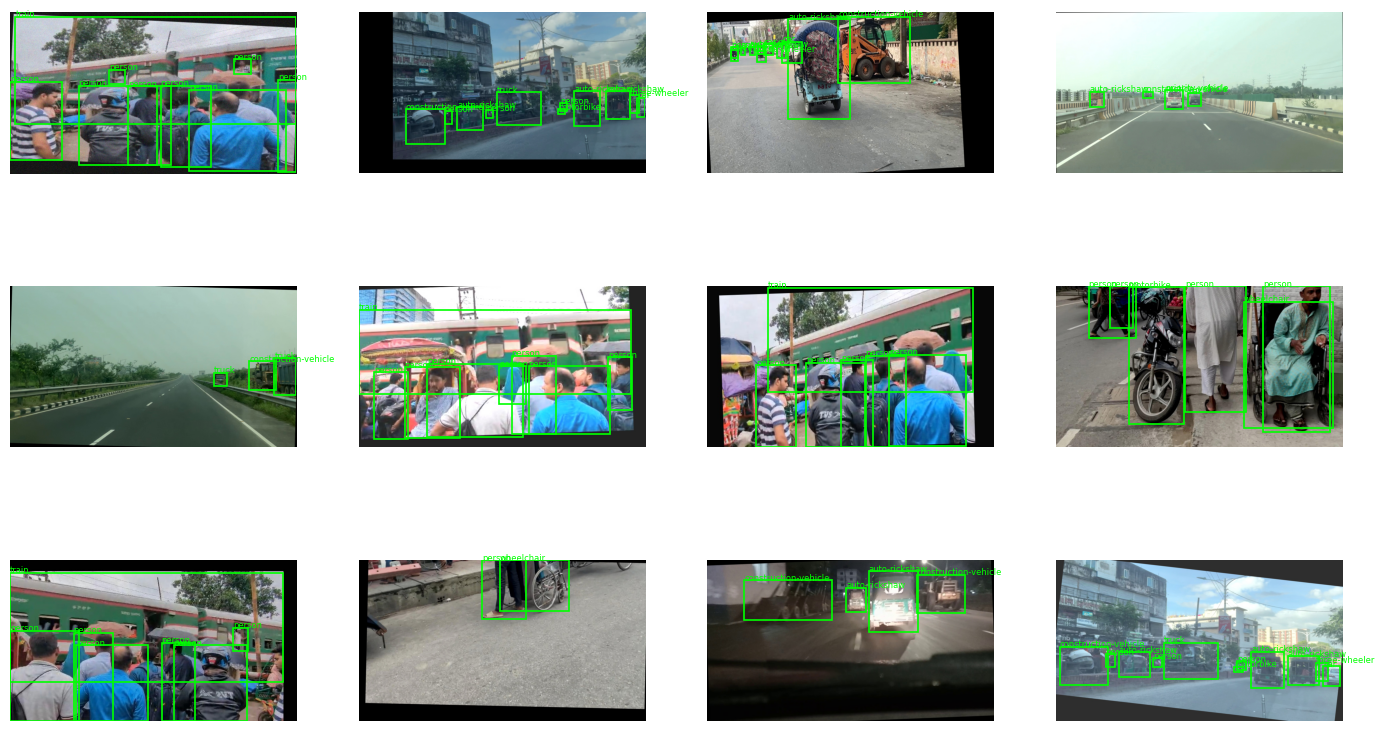

>>> Inspect the boxes above. If any box is misaligned, STOP and fix CELL 6 before training.


In [ ]:
# CELL 7 - MANDATORY QA: render augmented images with boxes and verify alignment by eye
import matplotlib.patches as mpatches

all_aug = [p for v in AUG_INDEX.values() for p in v]
sample = random.Random(SEED).sample(all_aug, k=min(12, len(all_aug)))
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, p in zip(axes.ravel(), sample):
    im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    H, W = im.shape[:2]
    ax.imshow(im)
    ax.axis('off')
    lp = AUG_DIR + '/labels/' + os.path.splitext(os.path.basename(p))[0] + '.txt'
    for cl, xc, yc, bw, bh in read_label(lp):
        ax.add_patch(mpatches.Rectangle(((xc - bw/2) * W, (yc - bh/2) * H), bw * W, bh * H,
                                        fill=False, lw=1.2, edgecolor='lime'))
        ax.text((xc - bw/2) * W, (yc - bh/2) * H - 2, CLASS_NAMES[cl], color='lime', fontsize=6)
for ax in axes.ravel()[len(sample):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIG_DIR + '/qa_augmentation_grid.png', dpi=150)
plt.show()
print('>>> Inspect the boxes above. If any box is misaligned, STOP and fix CELL 6 before training.')

In [ ]:
# CELL 8 - build EXP00 and EXP03 dataset trees (symlinks) + data.yaml, and log the confound
def link(src, dst):
    if not os.path.exists(dst):
        os.symlink(src, dst)

def fresh(d):
    if os.path.isdir(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

def link_split(root, split, images):
    di, dl = root + '/images/' + split, root + '/labels/' + split
    os.makedirs(di, exist_ok=True)
    os.makedirs(dl, exist_ok=True)
    for ip in images:
        link(ip, di + '/' + os.path.basename(ip))
        lp = label_path(ip)
        if os.path.exists(lp):
            link(lp, dl + '/' + os.path.basename(lp))

def write_yaml(root, path):
    with open(path, 'w') as f:
        yaml.safe_dump({'path': root, 'train': 'images/train', 'val': 'images/val',
                        'test': 'images/test', 'nc': NC,
                        'names': {i: n for i, n in enumerate(CLASS_NAMES)}}, f, sort_keys=False)
    return path

# ---- EXP00: baseline, untouched -------------------------------------------
R0 = EXP_DIR + '/EXP00'
fresh(R0)
for s in ['train', 'val', 'test']:
    link_split(R0, s, SPLIT_IMAGES[s])
YAML_EXP00 = write_yaml(R0, EXP_DIR + '/EXP00.yaml')

# ---- EXP03: oversampling + targeted augmentation ---------------------------
# Extra copies of a selected image are filled with augmented variants first, then with exact
# duplicates once the variants are exhausted. Both counts are logged for the Methodology.
R3 = EXP_DIR + '/EXP03'
fresh(R3)
for s in ['val', 'test']:
    link_split(R3, s, SPLIT_IMAGES[s])
link_split(R3, 'train', SPLIT_IMAGES['train'])

n_aug_used = 0
n_dup_used = 0
di, dl = R3 + '/images/train', R3 + '/labels/train'
for ip in SPLIT_IMAGES['train']:
    extra = REPEAT[ip] - 1
    if extra <= 0:
        continue
    stem = os.path.splitext(os.path.basename(ip))[0]
    variants = AUG_INDEX.get(ip, [])
    for k in range(extra):
        if k < len(variants):
            vp = variants[k]
            vstem = os.path.splitext(os.path.basename(vp))[0]
            link(vp, di + '/' + os.path.basename(vp))
            link(AUG_DIR + '/labels/' + vstem + '.txt', dl + '/' + vstem + '.txt')
            n_aug_used += 1
        else:
            ext = os.path.splitext(ip)[1]
            link(ip, di + '/' + stem + '__dup' + str(k) + ext)
            link(label_path(ip), dl + '/' + stem + '__dup' + str(k) + '.txt')
            n_dup_used += 1
YAML_EXP03 = write_yaml(R3, EXP_DIR + '/EXP03.yaml')

eff = len(os.listdir(R3 + '/images/train'))
COMPOSITION = {
    'EXP00': {'original_train_images': n_orig, 'effective_train_images': n_orig,
              'images_per_epoch': n_orig, 'epochs': EPOCHS,
              'approx_total_image_views': n_orig * EPOCHS},
    'EXP03': {'original_train_images': n_orig, 'augmented_copies_used': n_aug_used,
              'exact_duplicate_copies_used': n_dup_used, 'effective_train_images': eff,
              'images_per_epoch': eff, 'epochs': EPOCHS,
              'approx_total_image_views': eff * EPOCHS,
              'expansion_factor': round(eff / n_orig, 4)},
    'step_budget_matched': False,
    'disclosure': ('EXP03 sees more training images per epoch than EXP00 at a fixed epoch count, '
                   'so it also takes more optimisation steps. This is disclosed, not corrected for.'),
    'val_test_untouched': (len(os.listdir(R3 + '/images/val')) == len(SPLIT_IMAGES['val']) and
                           len(os.listdir(R3 + '/images/test')) == len(SPLIT_IMAGES['test'])),
}
print(json.dumps(COMPOSITION, indent=2))
assert COMPOSITION['val_test_untouched'], 'val/test were modified - abort.'
save_json('dataset_composition.json', COMPOSITION)

{
  "EXP00": {
    "original_train_images": 5967,
    "effective_train_images": 5967,
    "images_per_epoch": 5967,
    "epochs": 25,
    "approx_total_image_views": 149175
  },
  "EXP03": {
    "original_train_images": 5967,
    "augmented_copies_used": 140,
    "exact_duplicate_copies_used": 70,
    "effective_train_images": 6177,
    "images_per_epoch": 6177,
    "epochs": 25,
    "approx_total_image_views": 154425,
    "expansion_factor": 1.0352
  },
  "step_budget_matched": false,
  "disclosure": "EXP03 sees more training images per epoch than EXP00 at a fixed epoch count, so it also takes more optimisation steps. This is disclosed, not corrected for.",
  "val_test_untouched": true
}
saved /content/drive/MyDrive/badodd_paper/artifacts/dataset_composition.json


'/content/drive/MyDrive/badodd_paper/artifacts/dataset_composition.json'

In [ ]:
# CELL 9 - speed probe on the LARGER dataset; drop to imgsz=512 if an epoch exceeds ~2.5 min
import time
from ultralytics import YOLO

probe_dir = RUNS_LOCAL + '/probe'
if os.path.isdir(probe_dir):
    shutil.rmtree(probe_dir)
t0 = time.time()
YOLO(MODEL_CKPT).train(data=YAML_EXP03, epochs=1, imgsz=IMGSZ, batch=BATCH, seed=SEED,
                       optimizer=OPTIMIZER, lr0=LR0, amp=AMP, cache=CACHE, workers=WORKERS,
                       project=RUNS_LOCAL, name='probe', exist_ok=True, val=False,
                       plots=False, verbose=False)
probe_s = time.time() - t0
print('probe epoch (EXP03, imgsz=' + str(IMGSZ) + '): %.1f s' % probe_s)

if probe_s > EPOCH_TIME_BUDGET_S and IMGSZ != IMGSZ_FALLBACK:
    print('>>> exceeds ' + str(EPOCH_TIME_BUDGET_S) + 's -> falling back to imgsz=' + str(IMGSZ_FALLBACK))
    IMGSZ = IMGSZ_FALLBACK
else:
    print('>>> keeping imgsz=' + str(IMGSZ))
SPEED_PROBE = {'probe_epoch_seconds': round(probe_s, 1), 'probe_imgsz': 640,
               'budget_seconds': EPOCH_TIME_BUDGET_S, 'imgsz_used_for_all_runs': IMGSZ}
save_json('speed_probe.json', SPEED_PROBE)
shutil.rmtree(probe_dir, ignore_errors=True)
print('IMGSZ for both runs:', IMGSZ)

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/badodd_work/exp_datasets/EXP03.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=probe, nbs=64, nms=F

In [ ]:
# CELL 10 - training driver with per-epoch Drive mirroring and resume support
def mirror_cb(exp_id):
    dst_root = RUNS_DRIVE + '/' + exp_id
    def cb(trainer):
        try:
            for rel in ['weights/last.pt', 'weights/best.pt', 'results.csv', 'args.yaml']:
                src = os.path.join(str(trainer.save_dir), rel)
                if os.path.exists(src):
                    dst = os.path.join(dst_root, rel)
                    os.makedirs(os.path.dirname(dst), exist_ok=True)
                    shutil.copy2(src, dst)
        except Exception as e:
            print('drive mirror failed this epoch:', e)
    return cb

def restore_from_drive(exp_id):
    d, l = RUNS_DRIVE + '/' + exp_id, RUNS_LOCAL + '/' + exp_id
    if os.path.exists(d + '/weights/last.pt') and not os.path.exists(l + '/weights/last.pt'):
        os.makedirs(l + '/weights', exist_ok=True)
        for rel in ['weights/last.pt', 'weights/best.pt', 'results.csv', 'args.yaml']:
            if os.path.exists(d + '/' + rel):
                shutil.copy2(d + '/' + rel, l + '/' + rel)
        print('restored', exp_id, 'from Drive')
    return os.path.exists(l + '/weights/last.pt')

def run_experiment(exp_id, data_yaml):
    have_ckpt = restore_from_drive(exp_id)
    local = RUNS_LOCAL + '/' + exp_id
    t0 = time.time()
    if have_ckpt:
        print('--- ' + exp_id + ': resuming from last.pt ---')
        m = YOLO(local + '/weights/last.pt')
        m.add_callback('on_fit_epoch_end', mirror_cb(exp_id))
        m.train(resume=True)
    else:
        print('--- ' + exp_id + ': fresh start ---')
        m = YOLO(MODEL_CKPT)
        m.add_callback('on_fit_epoch_end', mirror_cb(exp_id))
        m.train(data=data_yaml, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, seed=SEED,
                deterministic=True, optimizer=OPTIMIZER, lr0=LR0, momentum=MOMENTUM,
                weight_decay=WEIGHT_DECAY, warmup_epochs=WARMUP_EPOCHS, patience=PATIENCE,
                amp=AMP, cache=CACHE, workers=WORKERS, pretrained=True, val=True, plots=True,
                project=RUNS_LOCAL, name=exp_id, exist_ok=True)
    mins = (time.time() - t0) / 60
    mirror_cb(exp_id)(m.trainer)
    for rel in ['results.png', 'args.yaml', 'results.csv']:
        if os.path.exists(local + '/' + rel):
            shutil.copy2(local + '/' + rel, RUNS_DRIVE + '/' + exp_id + '/' + rel)
    print(exp_id + ' wall-clock this session: %.1f min' % mins)
    return {'session_minutes': round(mins, 1)}

TRAIN_TIME = {}
TRAIN_TIME['EXP00'] = run_experiment('EXP00', YAML_EXP00)   # baseline

--- EXP00: fresh start ---
Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/badodd_work/exp_datasets/EXP00.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

In [ ]:
# CELL 11 - EXP03 (class-aware oversampling + targeted augmentation)
TRAIN_TIME['EXP03'] = run_experiment('EXP03', YAML_EXP03)
save_json('train_time.json', TRAIN_TIME)

--- EXP03: fresh start ---
Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/badodd_work/exp_datasets/EXP03.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

'/content/drive/MyDrive/badodd_paper/artifacts/train_time.json'

In [ ]:
# CELL 12 - final evaluation on the TEST split (first and only time test is touched)
def best_weights(exp_id):
    w = RUNS_LOCAL + '/' + exp_id + '/weights/best.pt'
    return w if os.path.exists(w) else RUNS_DRIVE + '/' + exp_id + '/weights/best.pt'

def evaluate(exp_id, data_yaml):
    w = best_weights(exp_id)
    m = YOLO(w)
    r = m.val(data=data_yaml, split='test', imgsz=IMGSZ, batch=BATCH, conf=0.001, iou=0.7,
              plots=True, verbose=False, project=RUNS_LOCAL, name=exp_id + '_test', exist_ok=True)
    idx = [int(v) for v in r.box.ap_class_index]
    per_class = {}
    for c in range(NC):
        sup = AUDIT['test']['instances'][c]
        if sup == 0:
            per_class[CLASS_NAMES[c]] = {'test_support': 0, 'train_support': tr[c],
                                         'AP50': None, 'AP50_95': None, 'precision': None,
                                         'recall': None, 'status': 'not_evaluable_zero_test_support'}
        elif c in idx:
            j = idx.index(c)
            per_class[CLASS_NAMES[c]] = {
                'test_support': sup, 'train_support': tr[c],
                'AP50': round(float(r.box.ap50[j]), 5),
                'AP50_95': round(float(r.box.ap[j]), 5),
                'precision': round(float(r.box.p[j]), 5),
                'recall': round(float(r.box.r[j]), 5),
                'status': 'evaluated'}
        else:
            per_class[CLASS_NAMES[c]] = {'test_support': sup, 'train_support': tr[c],
                                         'AP50': None, 'AP50_95': None, 'precision': None,
                                         'recall': None, 'status': 'absent_from_validator_output'}
    out = {'exp_id': exp_id, 'weights': w, 'imgsz': IMGSZ, 'split': 'test',
           'overall': {'precision': round(float(r.box.mp), 5),
                       'recall': round(float(r.box.mr), 5),
                       'mAP50': round(float(r.box.map50), 5),
                       'mAP50_95': round(float(r.box.map), 5)},
           'per_class': per_class}
    print(exp_id, json.dumps(out['overall'], indent=2))
    return out

TEST = {}
for e, y in [('EXP00', YAML_EXP00), ('EXP03', YAML_EXP03)]:
    TEST[e] = evaluate(e, y)

# group-level means over EVALUABLE classes only; 'extreme' is never averaged
GROUP = {}
for e in TEST:
    g = {}
    for grp in ['majority', 'medium', 'minority']:
        members = [r['name'] for r in CLASS_TABLE if r['group'] == grp and r['evaluable']]
        v50 = [TEST[e]['per_class'][n]['AP50'] for n in members
               if TEST[e]['per_class'][n]['AP50'] is not None]
        v95 = [TEST[e]['per_class'][n]['AP50_95'] for n in members
               if TEST[e]['per_class'][n]['AP50_95'] is not None]
        g[grp] = {'n_classes': len(members), 'classes': members,
                  'mean_AP50': round(float(np.mean(v50)), 5) if v50 else None,
                  'mean_AP50_95': round(float(np.mean(v95)), 5) if v95 else None}
    g['extreme'] = {'note': 'reported individually with raw support; never averaged',
                    'classes': [r['name'] for r in CLASS_TABLE if r['group'] == 'extreme']}
    GROUP[e] = g
print(json.dumps(GROUP, indent=2))
save_json('test_results.json', {'test_metrics': TEST, 'group_level': GROUP})

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,417,831 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 89.9±26.2 MB/s, size: 355.4 KB)
val: Scanning /content/badodd_work/exp_datasets/EXP00/labels/test... 2033 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2033/2033 453.8it/s 4.5s
val: New cache created: /content/badodd_work/exp_datasets/EXP00/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 3.6it/s 35.8s
                   all       2033      16153      0.754      0.549      0.608      0.386
Speed: 0.7ms preprocess, 4.3ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/badodd_work/runs/EXP00_test
EXP00 {
  "precision": 0.75406,
  "recall": 0.54879,
  "mAP50": 0.60779,
  "mAP50_95": 0.38579
}
Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (T

'/content/drive/MyDrive/badodd_paper/artifacts/test_results.json'

In [ ]:
# CELL 13 - efficiency, identical hardware and conditions for both runs [9]
EFF = {}
for e in ['EXP00', 'EXP03']:
    w = best_weights(e)
    m = YOLO(w)
    n_par = sum(p.numel() for p in m.model.parameters())
    imgs = SPLIT_IMAGES['test'][:220]
    for p in imgs[:20]:
        m.predict(p, imgsz=IMGSZ, device=0, verbose=False)
    torch.cuda.synchronize()
    t0 = time.time()
    for p in imgs[20:]:
        m.predict(p, imgsz=IMGSZ, device=0, verbose=False)
    torch.cuda.synchronize()
    ms = (time.time() - t0) / len(imgs[20:]) * 1000
    EFF[e] = {'parameters': int(n_par),
              'checkpoint_MB': round(os.path.getsize(w) / 1e6, 2),
              'inference_ms_per_image_batch1': round(ms, 2),
              'FPS_batch1': round(1000.0 / ms, 2),
              'n_images_timed': len(imgs[20:]),
              'imgsz': IMGSZ, 'gpu': ENV['gpu_name']}
print(json.dumps(EFF, indent=2))
save_json('efficiency.json', EFF)

{
  "EXP00": {
    "parameters": 9432823,
    "checkpoint_MB": 19.15,
    "inference_ms_per_image_batch1": 22.01,
    "FPS_batch1": 45.43,
    "n_images_timed": 200,
    "imgsz": 512,
    "gpu": "Tesla T4"
  },
  "EXP03": {
    "parameters": 9432823,
    "checkpoint_MB": 19.15,
    "inference_ms_per_image_batch1": 21.48,
    "FPS_batch1": 46.56,
    "n_images_timed": 200,
    "imgsz": 512,
    "gpu": "Tesla T4"
  }
}
saved /content/drive/MyDrive/badodd_paper/artifacts/efficiency.json


'/content/drive/MyDrive/badodd_paper/artifacts/efficiency.json'

55 test images contain a minority/extreme class


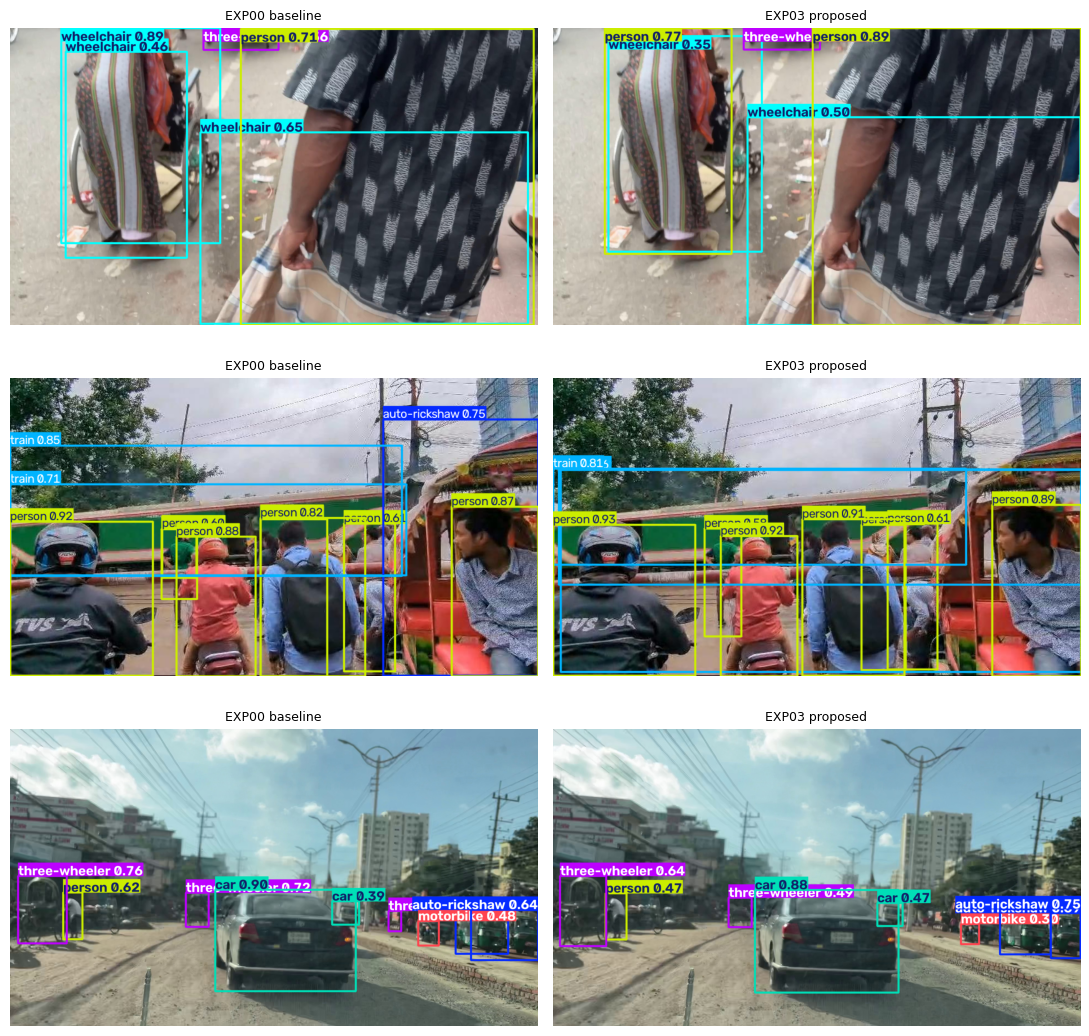

saved /content/drive/MyDrive/badodd_paper/artifacts/qualitative_examples.json


'/content/drive/MyDrive/badodd_paper/artifacts/qualitative_examples.json'

In [ ]:
# CELL 14 - Figure 4: qualitative comparison on minority-class test scenes
minority_ids = [r['id'] for r in CLASS_TABLE if r['group'] in ('minority', 'extreme') and r['evaluable']]
cands = [ip for ip in SPLIT_IMAGES['test']
         if any(c in minority_ids for c in {r[0] for r in read_label(label_path(ip))})]
print(len(cands), 'test images contain a minority/extreme class')
picks = random.Random(SEED).sample(cands, k=min(3, len(cands)))
m0, m3 = YOLO(best_weights('EXP00')), YOLO(best_weights('EXP03'))
fig, axes = plt.subplots(len(picks), 2, figsize=(11, 3.6 * len(picks)), squeeze=False)
for row, p in enumerate(picks):
    for col, (m, lab) in enumerate([(m0, 'EXP00 baseline'), (m3, 'EXP03 proposed')]):
        res = m.predict(p, imgsz=IMGSZ, conf=0.25, device=0, verbose=False)[0]
        axes[row][col].imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
        axes[row][col].set_title(lab, fontsize=9)
        axes[row][col].axis('off')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(FIG_DIR + '/fig4_qualitative.' + ext, dpi=300)
plt.show()
save_json('qualitative_examples.json', {'images_used': picks, 'conf_threshold': 0.25})

In [ ]:
# CELL 15 - print ONE consolidated block to paste back into the chat for Step 2
bundle = {
    'env': ENV,
    'reported_vs_observed': {'reported': REPORTED, 'observed': OBSERVED},
    'long_tail_stats': STATS,
    'class_table': CLASS_TABLE,
    'grouping_thresholds': {'Q1': Q1, 'median': MED, 'Q3': Q3,
                            'EXTREME_TRAIN_MAX': EXTREME_TRAIN_MAX,
                            'EXTREME_TEST_MAX': EXTREME_TEST_MAX},
    'manifest_stats': MANIFEST_STATS,
    'augmentation_stats': AUG_STATS,
    'dataset_composition': COMPOSITION,
    'training_protocol': {'model': MODEL_CKPT, 'imgsz': IMGSZ, 'epochs': EPOCHS, 'batch': BATCH,
                          'optimizer': OPTIMIZER, 'lr0': LR0, 'momentum': MOMENTUM,
                          'weight_decay': WEIGHT_DECAY, 'warmup_epochs': WARMUP_EPOCHS,
                          'seed': SEED, 'amp': AMP, 'cache': CACHE, 'workers': WORKERS,
                          'early_stopping': 'disabled', 'compute_tier': 'C', 'seeds_run': 1},
    'speed_probe': SPEED_PROBE,
    'train_time_minutes': TRAIN_TIME,
    'test_metrics': TEST,
    'group_level': GROUP,
    'efficiency': EFF,
}
save_json('PASTE_BACK.json', bundle)
print('=============== COPY EVERYTHING BELOW INTO THE CHAT ===============')
print(json.dumps(bundle, indent=1, default=str))
print('=============== END ===============')

saved /content/drive/MyDrive/badodd_paper/artifacts/PASTE_BACK.json
=============== COPY EVERYTHING BELOW INTO THE CHAT ===============
{
 "env": {
  "python": "3.13.15",
  "torch": "2.11.0+cu128",
  "cuda_version": "12.8",
  "cudnn": 91900,
  "ultralytics": "8.4.137",
  "albumentations": "2.0.8",
  "numpy": "2.1.3",
  "gpu_name": "Tesla T4",
  "gpu_total_mem_GB": 15.64
 },
 "reported_vs_observed": {
  "reported": {
   "total_images": 9825,
   "total_objects": 78943,
   "n_classes": 13,
   "split_images": {
    "train": 5896,
    "val": 1964,
    "test": 1965
   }
  },
  "observed": {
   "total_images": 10032,
   "total_objects": 80036,
   "n_classes": 13,
   "split_images": {
    "train": 5967,
    "val": 2032,
    "test": 2033
   }
  }
 },
 "long_tail_stats": {
  "Q1": 144.0,
  "median": 1885.0,
  "Q3": 3786.0,
  "mean": 3654.923076923077,
  "max": 18268.0,
  "min": 21.0,
  "max_over_median": 9.691246684350133,
  "min_over_median": 0.011140583554376658,
  "coefficient_of_variation": 